# Do Interest Rates Influence UK House Prices? An Empirical Analysis

## Introduction
This study investigates the relationship between interest rates and house prices in the United Kingdom. Understanding this relationship is important as interest rates influence borrowing costs and therefore play a key role in determining housing demand. When interest rates are low, mortgages become more affordable, potentially increasing demand for housing and driving up prices. However, higher interest rates increase borrowing costs, which may reduce demand and place downward pressure on house prices.

Using historical data on UK house prices and interest rates, this analysis explores whether changes in interest rates are associated with changes in house prices over time. The study begins with descriptive statistics and visualisations to identify general trends, followed by correlation analysis and regression modelling to quantify the relationship between the two variables.

The findings aim to provide insight into how monetary policy may influence the housing market while also highlighting the limitations of focusing on a single explanatory factor. 

In [266]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
interest = pd.read_csv("data/interest_rates.csv")
housing = pd.read_csv("data/house_prices.csv")

In [ ]:
housing = pd.read_csv("data/house_prices.csv", skiprows=1)
housing.columns = housing.iloc[0]
housing = housing[1:]
housing.columns = housing.columns.str.strip()

In [ ]:
housing = housing[['Period', 'New dwellings Price']]

In [273]:
housing['New dwellings Price'] = housing['New dwellings Price'].replace('[x]', None)
housing['New dwellings Price'] = housing['New dwellings Price'].str.replace(',', '')
housing['New dwellings Price'] = housing['New dwellings Price'].astype(float)

In [274]:
housing = housing.rename(columns={
    'Period': 'Date',
    'New dwellings Price': 'House_Price'
})

In [276]:
interest['Date Changed'] =pd.to_datetime(interest['Date Changed'])
interest = interest.sort_values('Date Changed')

/var/folders/k2/5276ndyn509dsvwfrn2sgdwr0000gn/T/ipykernel_73962/465014960.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  interest['Date Changed'] =pd.to_datetime(interest['Date Changed'])


In [277]:
interest['Quarter'] = interest['Date Changed'].dt.to_period('Q')

In [ ]:
interest_quarterly = interest.groupby('Quarter')['Rate'].mean().reset_index()

In [279]:
housing['Date'] = housing['Date'].str.replace(' Q1', '-03-31')
housing['Date'] = housing['Date'].str.replace(' Q2', '-06-30')
housing['Date'] = housing['Date'].str.replace(' Q3', '-09-30')
housing['Date'] = housing['Date'].str.replace(' Q4', '-12-31')

housing['Date'] = pd.to_datetime(housing['Date'])

In [ ]:
housing['Quarter'] = housing['Date'].dt.to_period('Q')

In [ ]:
merged = pd.merge(housing, interest_quarterly, on='Quarter')

## Data and Methodology
The analysis uses two main datasets: UK house prices and interest rates. House price data is measured using the price of new dwellings, providing a consistent measure of housing market trends over time. Interest rate data reflects changes in monetary policy and borrowing costs.

As the datasets were reported at different time intervals, several data preparation steps were needed. House price data was recorded quarterly, while interest rate data included more frequent observations. To ensure consistency, interest rates were converted into quarterly averages, allowing both datasets to be aligned on the same time scale. The use of quarterly data ensures consistency between datasets while also smoothing short-term fluctuations, making the analysis more reliable for identifying underlying trends.

The datasets were then merged based on their corresponding quarters to create a unified dataset for analysis. Any missing values were removed to ensure data quality. 

The analysis proceeds in several steps. First, summary statistics are presented to describe the key features of the data. This is followed by visualisation of trends over time, allowing for an assessment of the relationship between interest rates and house prices. A scatter plot and correlation analysis are then used to examine the strength and direction of the relationship. Finally, a regression model is estimated to quantify the impact of interest rates on house prices. 

## Summary Statistics
To begin the analysis, summary statistics are presented to provide an overview of the key features of the data, including the distribution of house prices and interest rates.

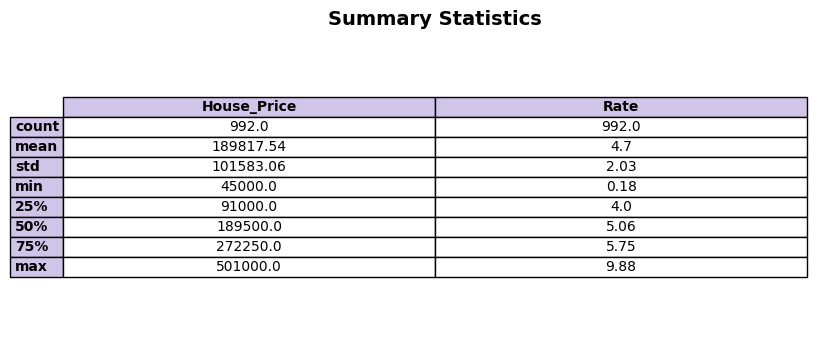

In [284]:
summary = merged[['House_Price', 'Rate']].describe()
fig, ax = plt.subplots(figsize=(8,4))
ax.axis('off')
table = ax.table(cellText=summary.round(2).values, colLabels=summary.columns, rowLabels=summary.index, loc='center', cellLoc='center')
purple = '#D1C4E9'
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(purple)
        cell.set_text_props(weight='bold', color='black')
    elif col == -1:
        cell.set_facecolor(purple)
        cell.set_text_props(weight='bold')
    else:
        cell.set_facecolor('white')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.title("Summary Statistics", fontsize=14, weight='bold')
plt.savefig("outputs/summary_stats.png", dpi=300, bbox_inches='tight')
plt.show()

The table shows summary statistics for house prices and interest rates. The average house price over the sample period is approximately £189,818, while the average interest rate is 4.70%. House prices show significant variation, ranging from £45,000 to £501,000, with a standard deviation of over £101,000. The relatively larger standard deviation of house prices compared to interest rates suggests that house prices have experienced greater absolute fluctuations over time. Interest rates also vary considerably, with values ranging from 0.18% to 9.88%. This wide range highlights major changes in monetary policy conditions across the sample period. Overall, the variation in both house prices and interest rates suggests that the data is suitable for further analysis of their relationship.

## Trends Over Time
To explore how house prices and interest rates have evolved over time, a time series plot is presented below.

In [237]:
#fig, ax1 = plt.subplots(figsize=(10,5))

#ax1.plot(merged['Date'], merged['House_Price'])
#ax1.set_ylabel('House Prices')

#ax2 = ax1.twinx()
#ax2.plot(merged['Date'], merged['Rate'])
#ax2.set_ylabel('Interest Rate (%)')

#plt.title("House Prices vs Interest Rates in the UK")
#plt.show()

In [285]:
merged.duplicated(subset='Quarter').sum()

np.int64(930)

In [286]:
merged = merged.groupby('Quarter').mean().reset_index()

In [287]:
merged['Date'] = merged['Quarter'].dt.to_timestamp()

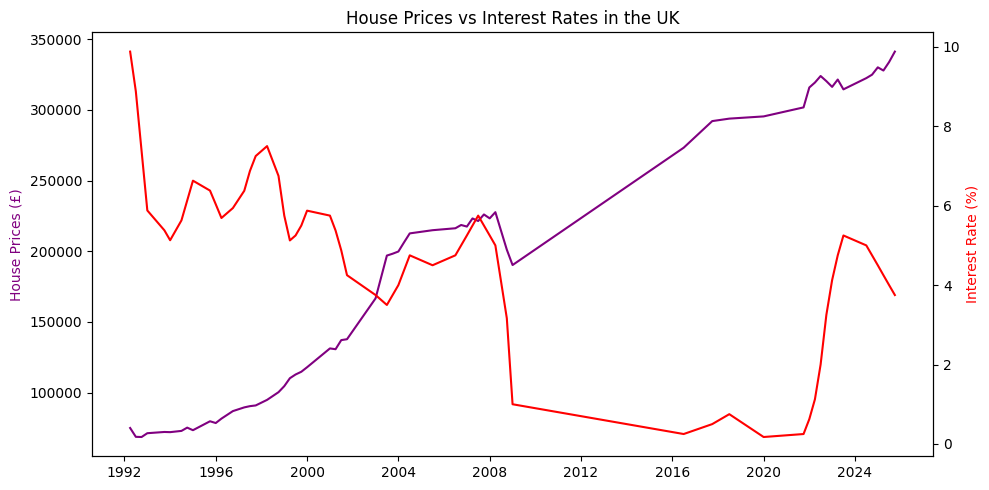

In [288]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(merged['Date'], merged['House_Price'], color='purple', label='House Prices')
ax1.set_ylabel('House Prices (£)', color='purple')

ax2 = ax1.twinx()
ax2.plot(merged['Date'], merged['Rate'], color='red', label='Interest Rate')
ax2.set_ylabel('Interest Rate (%)', color='red')

plt.title("House Prices vs Interest Rates in the UK")

fig.tight_layout()
plt.savefig("outputs/time_series.png", dpi=300, bbox_inches='tight')
plt.show()

This graph shows the trend of house prices and interest rates over the sample period. House prices experience a clear upward trend, increasing substantially over time, while interest rates show an overall downward trend. In particular, interest rates declined significantly in the period following the 2008 Financial Crisis, reflecting a period of monetary easing. During this time, house prices experience a temporary slowdown before continuing their upward path. More recently, interest rates have begun to rise again, while house prices appear to stabilise. This suggests a potential inverse relationship between the two variables, where lower interest rates are associated with higher house prices. However, the relationship doesn't appear perfectly consistent over time, indicating that additional factors may also influence house prices. 

## Relationship Between Interest Rates and House Prices
To further examine the relationship between interest rates and house prices, a scatter plot is presented below.

In [289]:
merged['Predicted'] = model.predict(X)

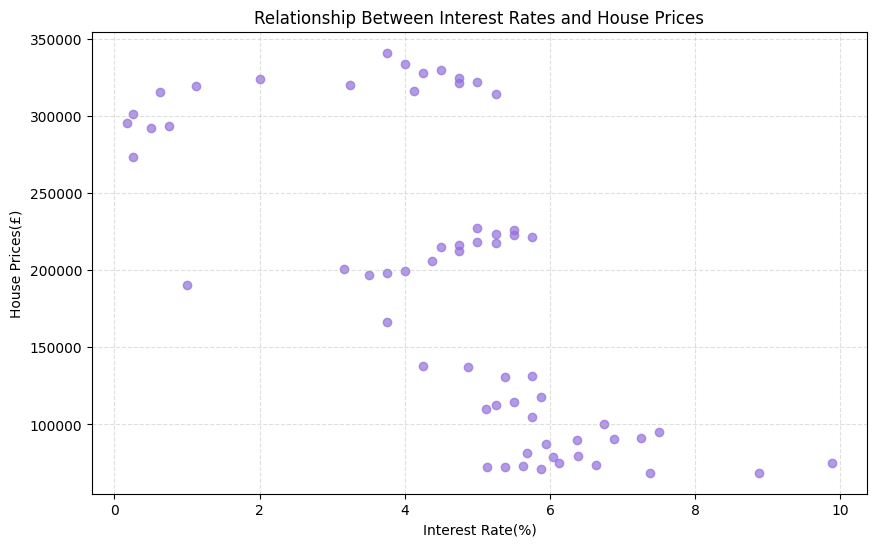

In [290]:
plt.figure(figsize=(10,6))
plt.scatter(merged['Rate'], merged['House_Price'], color='mediumpurple', alpha=0.7)
plt.xlabel("Interest Rate(%)")
plt.ylabel("House Prices(£)")
plt.title("Relationship Between Interest Rates and House Prices")
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig("outputs/scatter_plot.png", dpi=300, bbox_inches='tight')
plt.show()

The scatter plot provides a visual representation of the relationship between interest rates and house prices. There is a downward pattern, indicating that higher interest rates tend to be associated with lower house prices. However, the data points aren't tightly clustered, suggesting considerable variation around this relationship. This dispersion indicated that while an inverse relationship exists, interest rates alone don't fully explain movements in house prices.

## Correlation Analysis
To quantify the strength and direction of the relationship between interest rates and house prices, the correlation coefficient is calculated.

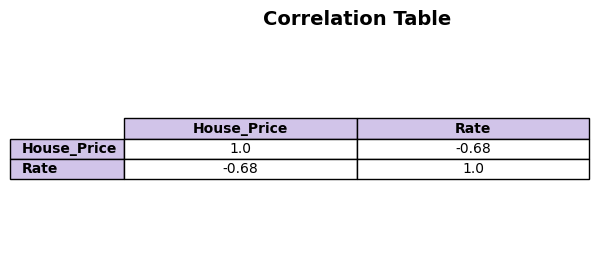

In [291]:
corr = merged[['House_Price', 'Rate']].corr()
fig, ax = plt.subplots(figsize=(5,3))
ax.axis('off')
table = ax.table(cellText=corr.round(2).values, colLabels=corr.columns, rowLabels=corr.index, loc='center', cellLoc='center')
purple = '#D1C4E9'
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(purple)
        cell.set_text_props(weight='bold', color='black')
    elif col == -1:
        cell.set_facecolor(purple)
        cell.set_text_props(weight='bold')
    else:
        cell.set_facecolor('white')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.title("Correlation Table", fontsize=14, weight='bold')
plt.savefig("outputs/correlation.png", dpi=300, bbox_inches='tight')
plt.show()

The correlation coefficient between interest rates and house prices is approximately -0.68, indicating a moderately strong negative relationship. This suggests that higher interest rates are generally associated with lower house prices, which is consistent with the patterns observed in both the time series and scatter plot. However, while the correlation is relatively strong, it doesn't imply causation, and other factors are also likely to influence house prices.

## Regression Analysis
To further quantify the relationship between interest rates and house prices, a regression model is estimated.

In [292]:
import statsmodels.api as sm

In [293]:
X = merged['Rate']
y = merged['House_Price']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# print(model.summary())

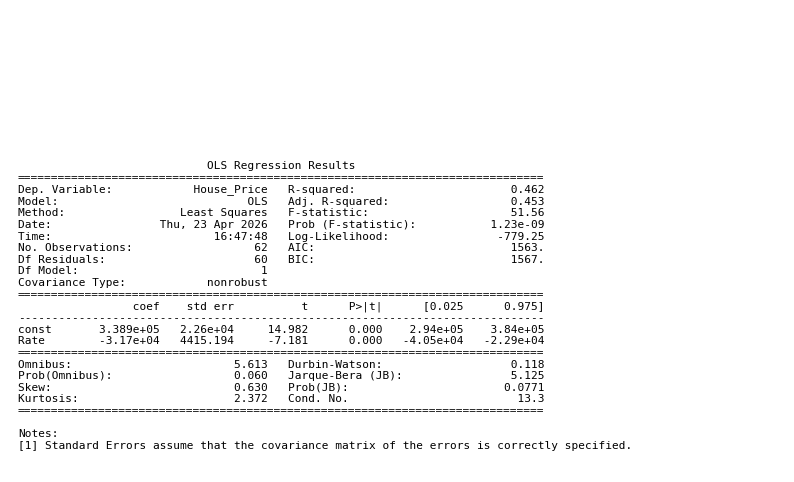

In [294]:
plt.figure(figsize=(10,6))
plt.text(0.01, 0.05, model.summary().as_text(), {'fontsize': 8}, fontfamily='monospace')
plt.axis('off')
plt.savefig("outputs/regression_full.png", dpi=300, bbox_inches='tight')
plt.show()

The regression results indicate a statistically significant negative relationship between interest rates and house prices. The coefficient on the interest rate variable suggests that a one percentage point increase in interest rates is associated with an approximate £31,700 decrease in house prices. The model's R-squared value of 0.462 indicates that interest rates explain around 46% of the variation in house prices, suggesting a moderate level of explanatory power. While the results support the hypothesis that higher interest rates are associated with lower house prices, other factors not included in the model are also likely to influence housing market dynamics. Overall, the regression results provide quantitative evidence supporting the existence of a negative relationship between interest rates and house prices. 

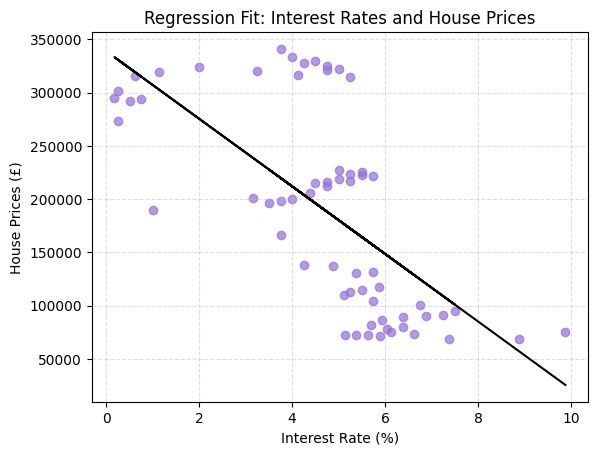

In [295]:
plt.scatter(merged['Rate'], merged['House_Price'], color='mediumpurple', alpha=0.7)
plt.plot(merged['Rate'], merged['Predicted'], color='black')
plt.xlabel("Interest Rate (%)")
plt.ylabel("House Prices (£)")
plt.title("Regression Fit: Interest Rates and House Prices")
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig("outputs/regression_plot.png", dpi=300, bbox_inches='tight')
plt.show()

The regression plot reinforces the negative relationship between interest rates and house prices by plotting a fitted line on the observed data. The downward slope of the line reflects the estimated coefficient from the regression model, indicating that increases in interest rates are associated with decreases in house prices. While the fitted line captures the overall trend in the data, the visible dispersion of observations around the line suggests that the model doesn't fully account for all variation in house prices. This highlights the presence of omitted variables and supports the proportion of variation explained by the model, as inducated by the R-squared value.

While the analysis identifies a clear negative relationship between interest rates and house prices, this relationship isn't constant across all economic conditions. In particular, during periods of strong housing demand or limited supply, house prices may continue to rise even when interest rates increase. This reflects the influence of underlying factors such as housing shortages, population growth, and government policies, which aren't captured in the model. As a result, the effect of interest rates on house prices should be interpreted within a wider economic context rather than on its own.

## Conclusion
This analysis finds clear evidence of a negative relationship between interest rates and house prices in the UK. Both visual and statistical results suggest that higher interest rates are associated with lower house prices. However, the relationship isn't perfect, and a significant portion of variation in house prices remains unexplained. This highlights the importance of additional factors such as income, housing supply, and broader economic conditions. Overall, the findings support the idea that monetary policy plays an important role in shaping house market outcomes, while also emphasising the complexity of house price dynamics.